Step 1 - setup

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# matplotlib.pylot is the library for creating graphs

# to get rid of scientific notation, use this line at the top of your colab file
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
#load dataset
HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

In [ ]:
# make sure python recognizes date column
HS_data['date'] = pd.to_datetime(HS_data['date'])

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


Step 2 - create spring and summer dummy variables

In [ ]:
HS_data['spring_DV'] = np.where(HS_data['date'].dt.month.isin([3,4,5]), 1, 0)
HS_data['summer_DV'] = np.where(HS_data['date'].dt.month.isin([6,7,8]), 1, 0)

Step 3 - create interaction terms

In [ ]:
HS_data['spring_interaction'] = HS_data['production'] * HS_data['spring_DV']
HS_data['summer_interaction'] = HS_data['production'] * HS_data['summer_DV']

Step 4 - split data into training/testing

In [ ]:
dt4training = HS_data.loc[HS_data['type'] == 'dt4training']
dt4testing  = HS_data.loc[HS_data['type'] == 'dt4testing']

Step 5 - create models

In [ ]:
#model A: spring model (production + spring dummy + interaction)
y_spring = dt4training.loc[:, 'revenue']
x_spring = dt4training.loc[:, ['production', 'spring_DV', 'spring_interaction']]
x_spring = sm.add_constant(x_spring)

model_spring = sm.OLS(y_spring, x_spring).fit()
model_spring.params

,0
const,5645359.67
production,17.00
spring_DV,-6781361.28
spring_interaction,23.65


In [ ]:
# model B: summer model
# need to give it a different specification --> coolDD
y_summer = dt4training.loc[:, 'revenue']
x_summer = dt4training.loc[:, ['production', 'coolDD', 'summer_DV', 'summer_interaction']]
x_summer = sm.add_constant(x_summer)

model_summer = sm.OLS(y_summer, x_summer).fit()
model_summer.params

,0
const,2112194.34
production,31.26
coolDD,-37258.43
summer_DV,860878.48
summer_interaction,7.60


Step 6 - predict and calculate MAPE for both models

In [ ]:

# Model A: Spring
x_spring_test = dt4testing.loc[:, ['production', 'spring_DV', 'spring_interaction']]
x_spring_test = sm.add_constant(x_spring_test)

spring_assessment = dt4testing.copy()
spring_assessment['spring_predicted_revenue'] = model_spring.predict(x_spring_test)
spring_assessment['spring_abs_pct_error'] = abs(
    (spring_assessment['revenue'] - spring_assessment['spring_predicted_revenue'])
    / spring_assessment['revenue']
)
spring_mape = spring_assessment['spring_abs_pct_error'].mean()
spring_mape

print(spring_mape)

# Model B: Summer
x_summer_test = dt4testing.loc[:, ['production', 'coolDD', 'summer_DV', 'summer_interaction']]
x_summer_test = sm.add_constant(x_summer_test)

summer_assessment = dt4testing.copy()
summer_assessment['summer_predicted_revenue'] = model_summer.predict(x_summer_test)
summer_assessment['summer_abs_pct_error'] = abs(
    (summer_assessment['revenue'] - summer_assessment['summer_predicted_revenue'])
    / summer_assessment['revenue']
)
summer_mape = summer_assessment['summer_abs_pct_error'].mean()
summer_mape

print(summer_mape)

0.2892751835381226
0.23543886021160895


Step 7 - visualize the models

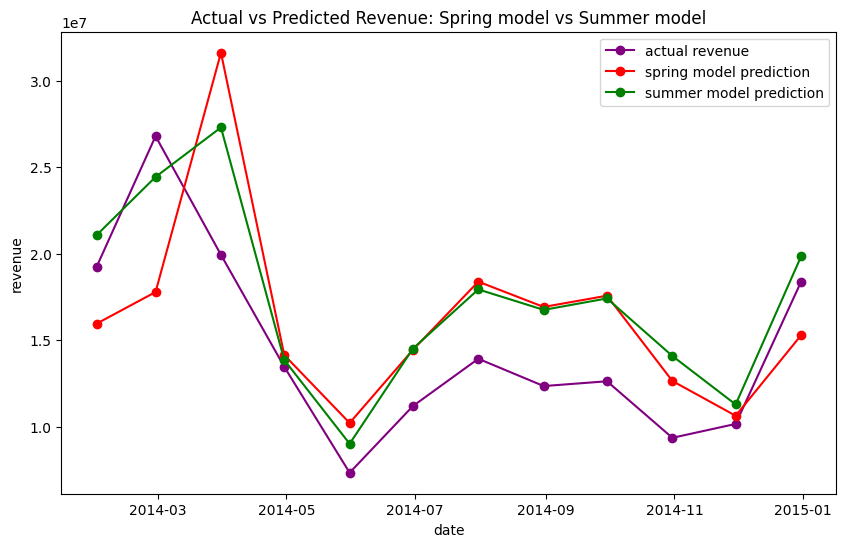

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Actual vs Predicted Revenue: Spring model vs Summer model')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(dt4testing['date'], spring_assessment['revenue'], marker='o', color='purple', label='actual revenue')
plt.plot(dt4testing['date'], spring_assessment['spring_predicted_revenue'], marker='o', color='red', label='spring model prediction')
plt.plot(dt4testing['date'], summer_assessment['summer_predicted_revenue'], marker='o', color='green', label='summer model prediction')

plt.legend()

# Memo: Revenue Forecasting Model Comparison

To: H&S Management
From: Fabiha, Analyst
Re: Recommended revenue forecasting model

The Summer model outperforms the Spring model, with a MAPE of approximately 23.5% versus 28.9%, and is the recommended model for forecasting H&S revenue going forward, although both models carry meaningful error and futher speficiations may need to be tested.

H&S asked for two revenue forecasting models, each incorporating at least one dummy variable and one interaction term, to identify which produces more reliable forecasts

Two seasonal dummy variables were created from the date field: spring_DV(months march, april, may) and summer_DV(months june, july, august). For each, an interaction term was built by multiplying the dummy by production, allowing the slope of the production-revenue relationship and the intercept to shift during the seasons

Model A(spring model) shows the regression on revenue, production, spring_DV, and spring interaction

Model B(summer model) shows the regression on revenue, production, coolDD, summer_DV, and summer_interaction. Cooling degree days (CoolDD) were added because summer revenue is tied to cooling demand, giving this model a disctinction from model A rather than just swapping the seasons

Both models were trained on the 2011-2013 data and tested against the 2014 period. Accuracy was assessed using the Mean Absolute Percentage Error (MAPE) on the test set.

Spring Model MAPE: approximately 28.9%
Summer Model MAPE: approximately 23.5%

The summer model produced lower forecased error across the test period, meaning its predictions deviated less on average from actual revenue.

The summer model (production + coolDD + summer_DV + summer_interaction) is recommended for forecasting going forward because it has a lower MAPE. Both models show meaninful error, so there may be room to test additional specifications. For example, combining seasonal dummies with heatDD, or testing fall/winter dummies because choosing a final forecasting approach.